🌟 **Daily Challenge: Strategic Analysis of Superstore Performance**

I use retail sales data to explore sales trends, geographic performance, profitable products, and discount patterns. My aim is to identify where the business can protect profit and support growth.

Data: `Sample - Superstore.csv` (the supplied US Superstore dataset). Keep this file beside the notebook and run the cells from top to bottom. Required packages: pandas, numpy, matplotlib, seaborn and ipywidgets. Use Jupyter Notebook or JupyterLab to operate the dropdown and slider. Static charts are included for viewers that do not run widgets.

The questions I investigate are: How do sales change over time? Which states drive sales, and are they profitable? Which products contribute the most profit? At which observed discount levels do losses become common?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from IPython.display import display

**🌟 1. Data Scoping and Preparation**

I load the supplied CSV with Windows-1252 encoding so special characters in product names are read correctly. Each row is an order line, so several rows can belong to one order. I keep postal codes as text because they are identifiers.

In [2]:
# Load and inspect the retail data.
df = pd.read_csv("Sample - Superstore.csv", encoding="cp1252",
                 dtype={"Postal Code": "string"})
df.columns = df.columns.str.strip()

print("Original shape:", df.shape)
print("Column names:", df.columns.tolist())
display(df.head(5))
df.info()
display(df.describe())
print("Missing values:")
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Original shape: (9994, 21)
Column names: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   string 
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicate rows: 0


In [3]:
# Clean text, remove exact duplicates, and check the required fields.
for column in df.select_dtypes(include=["object", "string"]).columns:
    df[column] = df[column].str.strip().replace("", pd.NA)

original_rows = len(df)
df = df.drop_duplicates().copy()
print("Exact duplicates removed:", original_rows - len(df))

for column in ["Order Date", "Ship Date"]:
    df[column] = pd.to_datetime(df[column], format="%m/%d/%Y", errors="coerce")

required = ["Order Date", "Sales", "Profit", "Discount", "Category", "State", "Product Name"]
missing_required = df[required].isna().any(axis=1)
print("Rows excluded for missing required values:", missing_required.sum())
df = df.loc[~missing_required].copy()

print("Remaining missing values:", df.isna().sum().sum())
print("Non-positive sales:", (df["Sales"] <= 0).sum())
print("Discounts outside 0–1:", (~df["Discount"].between(0, 1)).sum())
print("Ship dates before order dates:", (df["Ship Date"] < df["Order Date"]).sum())
print("Distinct orders:", df["Order ID"].nunique())
print("Date range:", df["Order Date"].min().date(), "to", df["Order Date"].max().date())
display(df[["Order Date", "Ship Date"]].dtypes)

Exact duplicates removed: 0
Rows excluded for missing required values: 0
Remaining missing values: 0
Non-positive sales: 0
Discounts outside 0–1: 0
Ship dates before order dates: 0
Distinct orders: 5009
Date range: 2014-01-03 to 2017-12-30


Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

The supplied dataset contains 9,994 rows, with no missing values or exact duplicates, so all rows are retained. I do not impute sales, profit, discounts, or dates because invented values would change the business results. The code reports and excludes rows missing essential analysis fields if the input changes. Missing postal codes would remain missing because none of these analyses needs them.

Repeated order IDs are expected for orders with several products and are not duplicates. Negative profit is a business outcome, so I keep those rows.

In [4]:
# Create date features and protect margin calculations against zero sales.
df["Profit Margin"] = df["Profit"].div(df["Sales"].replace(0, np.nan)) * 100
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month-Year"] = df["Order Date"].dt.to_period("M")
df["Loss"] = df["Profit"] < 0

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = total_profit / total_sales
display(df[["Sales", "Profit", "Profit Margin", "Order Year", "Order Month"]].head())
print(f"Total sales: ${total_sales:,.2f}")
print(f"Total profit: ${total_profit:,.2f}")
print(f"Overall profit margin: {overall_margin:.2%}")

,Sales,Profit,Profit Margin,Order Year,Order Month
0,261.9600,41.9136,16.00,2016,11
1,731.9400,219.5820,30.00,2016,11
2,14.6200,6.8714,47.00,2016,6
3,957.5775,-383.0310,-40.00,2015,10
4,22.3680,2.5164,11.25,2015,10


Total sales: $2,297,200.86
Total profit: $286,397.02
Overall profit margin: 12.47%


I calculate the overall margin from total profit divided by total sales. Averaging row margins would give small and large sales equal weight and answer a different question.

**🌟 2. Monthly Sales Trends (Matplotlib)**

I total sales by month in chronological order. The dropdown compares each category with the overall trend. The first chart is a saved static view of all categories.

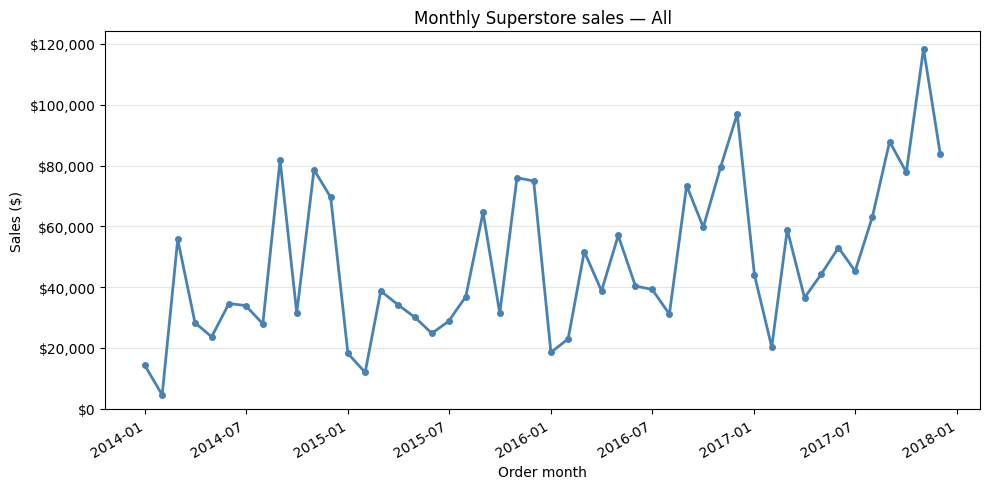

In [5]:
# Plot monthly sales for all categories or one selected category.
month_index = pd.period_range(df["Order Month-Year"].min(),
                             df["Order Month-Year"].max(), freq="M")

def plot_monthly_sales(category="All"):
    selected = df if category == "All" else df[df["Category"] == category]
    monthly_sales = selected.groupby("Order Month-Year")["Sales"].sum().reindex(month_index, fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(monthly_sales.index.to_timestamp(), monthly_sales.values,
            marker="o", color="steelblue", linewidth=2, markersize=4)
    ax.set_title(f"Monthly Superstore sales — {category}")
    ax.set_xlabel("Order month")
    ax.set_ylabel("Sales ($)")
    ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

plot_monthly_sales()

In [6]:
# Change the category to explore the monthly trend.
category_dropdown = widgets.Dropdown(options=["All"] + sorted(df["Category"].unique()),
                                     value="All", description="Category:")
monthly_widget = widgets.interactive(plot_monthly_sales, category=category_dropdown)
display(monthly_widget)

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

In [7]:
# Support the trend interpretation with annual and seasonal totals.
annual_summary = df.groupby("Order Year")[["Sales", "Profit"]].sum()
annual_summary["Sales growth (%)"] = annual_summary["Sales"].pct_change() * 100
category_year_sales = df.pivot_table(index="Order Year", columns="Category",
                                    values="Sales", aggfunc="sum")
seasonal_sales = df.groupby("Order Month")["Sales"].sum().to_frame()
display(annual_summary.round(2))
display(category_year_sales.round(2))
display(category_year_sales.pct_change().mul(100).round(2))
display(seasonal_sales.round(2))

,Sales,Profit,Sales growth (%)
Order Year,,,
2014,484247.50,49543.97,NaN
2015,470532.51,61618.60,-2.83
2016,609205.60,81795.17,29.47
2017,733215.26,93439.27,20.36


Category,Furniture,Office Supplies,Technology
Order Year,,,
2014,157192.85,151776.41,175278.23
2015,170518.24,137233.46,162780.81
2016,198901.44,183939.98,226364.18
2017,215387.27,246097.18,271730.81


Category,Furniture,Office Supplies,Technology
Order Year,,,
2014,NaN,NaN,NaN
2015,8.48,-9.58,-7.13
2016,16.65,34.03,39.06
2017,8.29,33.79,20.04


,Sales
Order Month,
1,94924.84
2,59751.25
3,205005.49
4,137762.13
5,155028.81
6,152718.68
7,147238.10
8,159044.06
9,307649.95


Sales fall by 2.8% in 2015, then grow by 29.5% in 2016 and 20.4% in 2017. All three categories increase sales in 2016 and 2017. Technology leads sales in 2017.

November has the largest combined monthly sales across the four years ($352,461); February has the smallest ($59,751). The monthly chart suggests stronger late-year demand. I would prepare inventory for that period, while checking individual years before treating four years of history as a reliable forecast.

**🌟 3. Geographic Sales Performance (Matplotlib)**

I sort states by total sales and use a horizontal chart so the names remain readable. The slider changes how many leading states are shown. I also check their profit because high sales do not always mean good business performance.

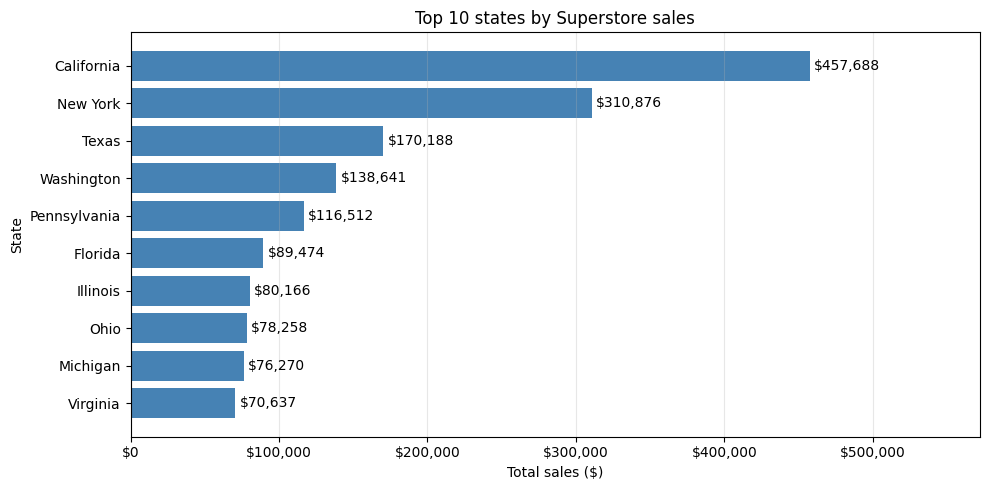

Top 10 share of sales: 69.2%


,Sales,Profit,Profit Margin (%)
State,,,
California,457687.63,76381.39,16.69
New York,310876.27,74038.55,23.82
Texas,170188.05,-25729.36,-15.12
Washington,138641.27,33402.65,24.09
Pennsylvania,116511.91,-15559.96,-13.35
Florida,89473.71,-3399.30,-3.80
Illinois,80166.10,-12607.89,-15.73
Ohio,78258.14,-16971.38,-21.69
Michigan,76269.61,24463.19,32.07


In [8]:
# Rank states and compare their sales with profit.
state_summary = df.groupby("State")[["Sales", "Profit"]].sum().sort_values("Sales")
state_summary["Profit Margin (%)"] = state_summary["Profit"] / state_summary["Sales"] * 100
state_sales = state_summary["Sales"]

def plot_top_states(top_n=10):
    top_states = state_sales.tail(top_n)
    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.3)))
    bars = ax.barh(top_states.index, top_states.values, color="steelblue")
    ax.bar_label(bars, labels=[f"${value:,.0f}" for value in top_states], padding=3)
    ax.set_title(f"Top {top_n} states by Superstore sales")
    ax.set_xlabel("Total sales ($)")
    ax.set_ylabel("State")
    ax.set_xlim(0, top_states.max() * 1.25)
    ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Top {top_n} share of sales: {top_states.sum() / total_sales:.1%}")

plot_top_states()
display(state_summary.tail(10).sort_values("Sales", ascending=False).round(2))

In [9]:
# Choose the number of states displayed.
top_n_slider = widgets.IntSlider(min=5, max=len(state_sales), value=10,
                                description="Top N states:", continuous_update=False)
states_widget = widgets.interactive(plot_top_states, top_n=top_n_slider)
display(states_widget)

interactive(children=(IntSlider(value=10, continuous_update=False, description='Top N states:', max=49, min=5)…

California leads sales with $457,688. The top five states account for 52.0% of sales across 49 represented states, so sales are concentrated in a small group of markets.

Texas loses $25,729 and Pennsylvania loses $15,560 despite ranking third and fifth by sales. I would review their discount and product mix before increasing sales activity there. California and New York combine high sales with positive profit.

**🌟 4. Top 10 Most Profitable Products (Seaborn)**

I group by product name and rank total profit. The labels show profit to the nearest cent. These are total profit contributions, not profit margins or profits per unit.

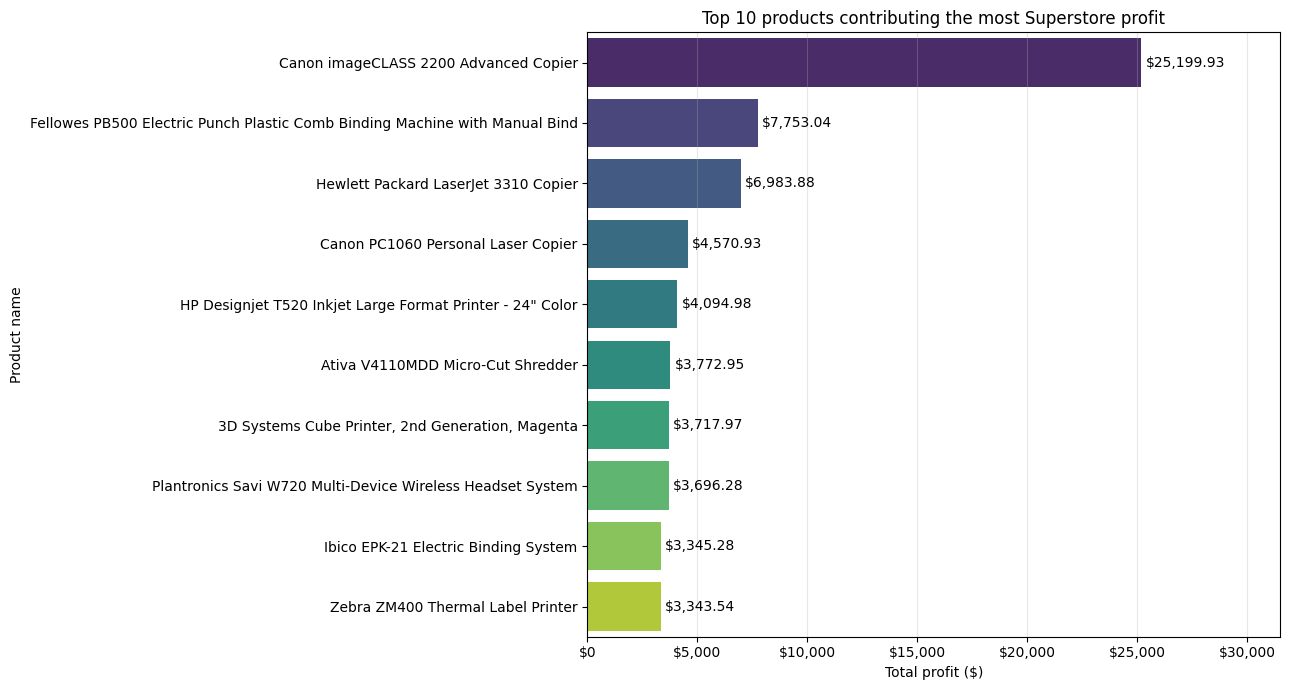

Top 10 share of net profit: 23.2%


,Product Name,Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.93
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.04
2,Hewlett Packard LaserJet 3310 Copier,6983.88
3,Canon PC1060 Personal Laser Copier,4570.93
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.98
5,Ativa V4110MDD Micro-Cut Shredder,3772.95
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.97
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.28
8,Ibico EPK-21 Electric Binding System,3345.28
9,Zebra ZM400 Thermal Label Printer,3343.54


In [10]:
# Show the products contributing the most total profit.
product_profit = df.groupby("Product Name")["Profit"].sum().nlargest(10)
product_summary = product_profit.rename("Profit").reset_index()

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(data=product_summary, x="Profit", y="Product Name", hue="Product Name",
            palette="viridis", dodge=False, legend=False, errorbar=None, ax=ax)
for container in ax.containers:
    ax.bar_label(container, labels=[f"${bar.get_width():,.2f}" for bar in container], padding=3)
ax.set_title("Top 10 products contributing the most Superstore profit")
ax.set_xlabel("Total profit ($)")
ax.set_ylabel("Product name")
ax.set_xlim(0, product_profit.max() * 1.25)
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Top 10 share of net profit: {product_profit.sum() / total_profit:.1%}")
display(product_summary.round(2))

The Canon imageCLASS 2200 Advanced Copier contributes $25,199.93, making it the most profitable product by total profit. The top 10 products contribute $66,478.78. I would protect availability of these products and review their demand before expanding stock. Their share uses net profit as its denominator, including losses on other products.

**🌟 5. Discount and Profit (Seaborn)**

I compare discount with order-line profit and use color to identify categories. The dashed line summarizes the overall association. Tables of actual discount levels show loss rates and group sizes, which are harder to read from overlapping points.

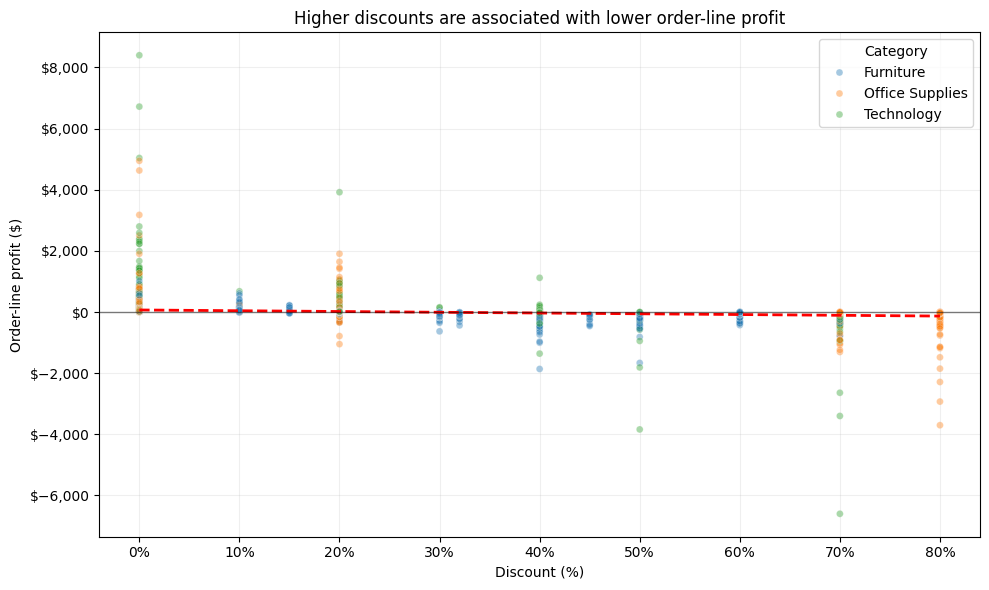

In [11]:
# Explore the association between discounts and order-line profit.
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category",
                alpha=0.4, s=25, ax=ax)
sns.regplot(data=df, x="Discount", y="Profit", scatter=False, ci=None,
            color="red", line_kws={"linestyle": "--", "linewidth": 2}, ax=ax)
ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.set_title("Higher discounts are associated with lower order-line profit")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Order-line profit ($)")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [12]:
# Calculate loss rates at each observed discount, overall and by category.
discount_summary = df.groupby("Discount").agg(
    Rows=("Profit", "size"), Sales=("Sales", "sum"), Profit=("Profit", "sum"),
    Average_profit=("Profit", "mean"), Loss_rate=("Loss", "mean")
)
discount_summary["Loss rate (%)"] = discount_summary.pop("Loss_rate") * 100
discount_summary["Profit Margin (%)"] = discount_summary["Profit"] / discount_summary["Sales"] * 100

category_discount = df.groupby(["Category", "Discount"]).agg(
    Rows=("Profit", "size"), Average_profit=("Profit", "mean"), Loss_rate=("Loss", "mean")
)
category_discount["Loss rate (%)"] = category_discount.pop("Loss_rate") * 100
display(discount_summary.round(2))
display(category_discount.round(2))

high_discount = df[df["Discount"] > 0.2]
print(f"Order lines above 20% discount: {len(high_discount):,}")
print(f"Average profit above 20% discount: ${high_discount['Profit'].mean():,.2f}")
print(f"Loss rate above 20% discount: {high_discount['Loss'].mean():.1%}")

category_summary = df.groupby("Category")[["Sales", "Profit"]].sum()
category_summary["Profit Margin (%)"] = category_summary["Profit"] / category_summary["Sales"] * 100
display(category_summary.round(2))

,Rows,Sales,Profit,Average_profit,Loss rate (%),Profit Margin (%)
Discount,,,,,,
0.00,4798,1087908.47,320987.60,66.90,0.00,29.51
0.10,94,54369.35,9029.18,96.06,4.26,16.61
0.15,52,27558.52,1418.99,27.29,32.69,5.15
0.20,3657,764594.37,90337.31,24.70,13.73,11.82
0.30,227,103226.66,-10369.28,-45.68,91.63,-10.05
0.32,27,14493.46,-2391.14,-88.56,100.00,-16.50
0.40,206,116417.78,-23057.05,-111.93,87.38,-19.81
0.45,11,5484.97,-2493.11,-226.65,100.00,-45.45
0.50,66,58918.54,-20506.43,-310.70,100.00,-34.80


Rows  Average_profit  Loss rate (%)
Category        Discount                                     
Furniture       0.00       836           69.54           0.00
                0.10        76           93.57           5.26
                0.15        52           27.29          32.69
                0.20       615           10.19          26.99
                0.30       222          -48.18          93.24
                0.32        27          -88.56         100.00
                0.40        75         -215.83         100.00
                0.45        11         -226.65         100.00
                0.50        54         -238.36         100.00
                0.60       138          -43.08         100.00
                0.70        15         -259.66         100.00
Office Supplies 0.00      3129           41.71           0.00
                0.10        16           67.88           0.00
                0.20      2201           17.28           9.36
                0.70       380          -43.69         100.00
                0.80       300         -101.80         100.00
Technology      0.00       833          158.88           0.00
                0.10         2          416.04           0.00
                0.20       841           54.74          15.46
                0.30         5           65.21          20.00
                0.40       131          -52.44          80.15
                0.50        12         -636.27         100.00
                0.70        23         -851.27         100.00

Order lines above 20% discount: 1,393
Average profit above 20% discount: $-97.18
Loss rate above 20% discount: 96.8%


,Sales,Profit,Profit Margin (%)
Category,,,
Furniture,741999.80,18451.27,2.49
Office Supplies,719047.03,122490.80,17.04
Technology,836154.03,145454.95,17.40


The 1,393 order lines discounted above 20% have an average profit of $-97.18; 96.8% lose money. The first observed overall discount level with negative average profit is 30%. There are no observations between 20% and 30%, so the exact transition is unknown.

The category table shows different patterns: all three categories have positive average profit at 20%, but 27.0% of Furniture order lines at that level still lose money. Furniture has negative average profit at 30%, while Technology has positive average profit at 30% based on only five lines and negative average profit at 40%. Office Supplies only has 70% and 80% observations above 20%, both entirely loss-making. A 20% cap is therefore not a guarantee of profitability. I would require a margin check for Furniture promotions and review discounts above 20% across all categories, then test revised rules on a limited scale.

These are associations, not evidence that discounts alone cause the losses. Product mix, quantity, region, and the reasons discounts were offered may also matter. The regression line does not identify a safe threshold for every product.

**🌟 6. Methodology and Tooling Review**

I use exploratory charts to investigate patterns and explanatory charts to communicate a specific result. The dropdown and slider support exploration; the ranked product chart and its value labels communicate the leading profit contributors.

| Tool | What worked well in this analysis | Limitation |
|---|---|---|
| Matplotlib | Direct control of axes, currency labels, figure size and widget callback plots. | Grouping, colors and statistical summaries need more explicit code. |
| Seaborn | Clear category colors and concise bar, scatter and regression plots using DataFrames. | I still use Matplotlib to finish labels, formatting and layout. |

For these time-series and state charts, I prefer Matplotlib because I can directly control their layout. For quick category comparisons and statistical exploration, I prefer Seaborn. Both can produce stakeholder-facing charts and work with ipywidgets; the choice depends on the chart rather than a strict exploration-versus-presentation rule. I do not infer general rendering speed from a single timing run.

**🌟 7. Executive Summary and Recommendations**

- **Business performance:** Sales total $2,297,200.86 and profit totals $286,397.02, giving a 12.47% overall margin. Furniture has a 2.49% margin, compared with 17.03% for Office Supplies and 17.40% for Technology. Prioritize Furniture margin review.
- **Growth and demand:** Sales grow 20.4% in 2017. November has the largest combined sales across years. Prepare inventory and staffing for late-year demand while checking category-specific trends.
- **Geography:** The top five states generate 52.0% of sales. Review the product and discount mix in loss-making Texas and Pennsylvania before pursuing more volume there.
- **Products:** The Canon imageCLASS 2200 Advanced Copier contributes $25,199.93 in profit. Protect availability of leading profit contributors, with stock decisions supported by demand and inventory information.
- **Discounts:** 96.8% of order lines above 20% discount lose money. Introduce margin-based review of deeper discounts and stricter Furniture checks; measure profit, sales and loss rate during a controlled pilot.

These findings describe the supplied 2014–2017 sample. They do not establish causation or predict current demand. Revenue alone cannot determine where expansion will be profitable, and this file does not contain inventory levels or the full context behind discount decisions.